<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [10]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level=2)


# Section 1: Unsupervised Evaluation and Instance Difficulty

This notebook opens the workshop with a simple message: clustering evaluation usually depends on aggregate metrics, but those metrics can hide which instances are genuinely easy or difficult for the models.


## Learning Goals

By the end of this section, participants should be able to:

- explain why aggregate clustering metrics are useful but incomplete;
- compare an easy and a hard toy clustering problem;
- inspect which instances are consistently ambiguous across models;
- motivate the move from aggregate evaluation to latent ability.


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

from utils.handson import (
    evaluate_clustering_models_on_dataset,
    make_toy_clustering_dataset,
    plot_clustering_dataset,
    plot_clustering_instance_difficulty,
    summarize_clustering_instance_difficulty,
    summarize_clustering_results,
)


## Step 1: Build an easy clustering dataset

We start with a well-separated clustering problem. This gives the room an intuitive baseline for what an *easy* unsupervised structure looks like.


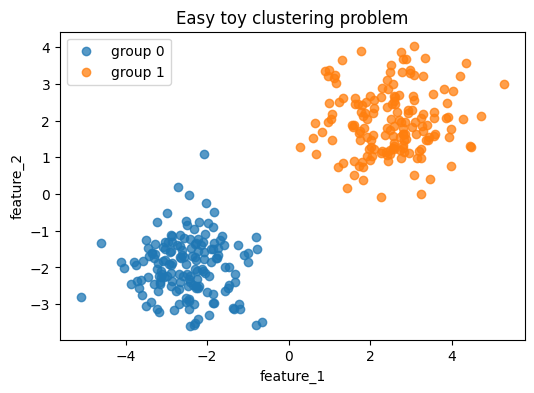

In [12]:
easy_df = make_toy_clustering_dataset(
    scenario='easy_blobs',
    n_samples=320,
    random_state=42,
)

ax = plot_clustering_dataset(easy_df, title='Easy toy clustering problem')
plt.show()


In [13]:
easy_assignments = evaluate_clustering_models_on_dataset(
    easy_df,
    scenario='easy_blobs',
    random_state=42,
)
easy_summary = summarize_clustering_results(easy_assignments)
easy_summary.round(3)


/Users/manuelfjr/Library/Caches/pypoetry/virtualenvs/latent-ability-ml-gUy-rFEi-py3.13/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,scenario,model,ari,n_predicted_clusters,silhouette,calinski_harabasz,davies_bouldin
0,easy_blobs,agglomerative,1.0,2,0.767,2308.063,0.329
1,easy_blobs,kmeans,1.0,2,0.767,2308.063,0.329
2,easy_blobs,spectral,1.0,2,0.767,2308.063,0.329


## Step 2: Make the clustering problem harder

We now move to a nonlinearly separable and noisier scenario. The key point is that the notion of “good clustering” becomes more sensitive to model assumptions.


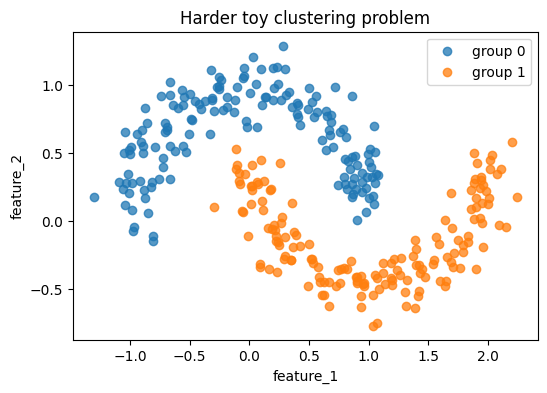

In [14]:
hard_df = make_toy_clustering_dataset(
    scenario='hard_moons',
    n_samples=320,
    random_state=7,
)

ax = plot_clustering_dataset(hard_df, title='Harder toy clustering problem')
plt.show()

In [15]:
hard_assignments = evaluate_clustering_models_on_dataset(
    hard_df,
    scenario='hard_moons',
    random_state=7,
)
hard_summary = summarize_clustering_results(hard_assignments)
hard_summary.round(3)


,scenario,model,ari,n_predicted_clusters,silhouette,calinski_harabasz,davies_bouldin
0,hard_moons,spectral,0.722,2,0.398,299.124,0.930
1,hard_moons,kmeans,0.235,2,0.485,472.211,0.773
2,hard_moons,agglomerative,0.194,2,0.476,453.296,0.776


## Step 3: Compare scenarios side by side

On the easy dataset, several models may look similarly strong. On the harder dataset, the ranking changes and the aggregate metrics become more revealing, but still incomplete.


In [16]:
comparison = pd.concat([easy_summary, hard_summary], ignore_index=True)
comparison.round(3)


,scenario,model,ari,n_predicted_clusters,silhouette,calinski_harabasz,davies_bouldin
0,easy_blobs,agglomerative,1.000,2,0.767,2308.063,0.329
1,easy_blobs,kmeans,1.000,2,0.767,2308.063,0.329
2,easy_blobs,spectral,1.000,2,0.767,2308.063,0.329
3,hard_moons,spectral,0.722,2,0.398,299.124,0.930
4,hard_moons,kmeans,0.235,2,0.485,472.211,0.773
5,hard_moons,agglomerative,0.194,2,0.476,453.296,0.776


## Step 4: Which instances are hard?

To move toward IRT, we now stop looking only at model-level metrics and inspect instance-level difficulty using **agreement across clustering models**.


In [17]:
hard_instance_summary = summarize_clustering_instance_difficulty(hard_assignments)
hard_instance_summary.head(10).round(3)


100%|██████████| 3/3 [00:00<00:00, 266.01it/s]


,instance_id,feature_1,feature_2,label,scenario,mean_model_agreement,difficulty_proxy
0,28,0.781,0.678,0,hard_moons,0.346,0.654
1,147,0.643,0.524,0,hard_moons,0.346,0.654
2,155,0.864,0.921,0,hard_moons,0.346,0.654
3,176,0.704,0.547,0,hard_moons,0.346,0.654
4,248,0.675,0.631,0,hard_moons,0.346,0.654
5,260,0.760,0.657,0,hard_moons,0.346,0.654
6,310,0.810,0.621,0,hard_moons,0.346,0.654
7,56,0.526,-0.275,1,hard_moons,0.361,0.639
8,76,0.369,-0.188,1,hard_moons,0.361,0.639
9,81,0.236,-0.372,1,hard_moons,0.361,0.639


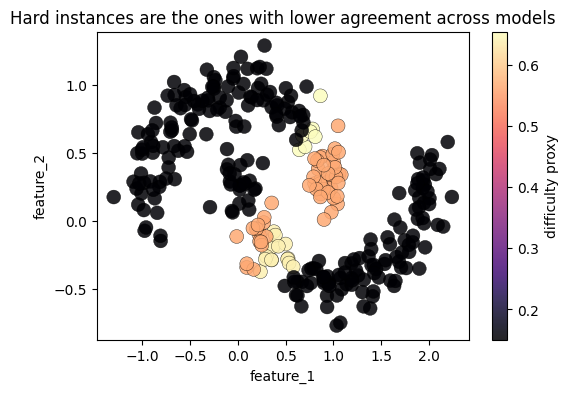

In [18]:
ax = plot_clustering_instance_difficulty(hard_instance_summary)
ax.set_title('Hard instances are the ones with lower agreement across models')
plt.show()


## Discussion Prompts

- Which metric changes most from the easy to the hard scenario?
- Which model seems strongest on easy blobs and which one adapts better to moons?
- Which regions of the dataset produce less agreement across models?
- What is missing when we summarize the whole dataset using only one metric?


## Bridge to Section 2

This is the key transition: if some items are harder than others, then evaluation should separate **model ability** from **item difficulty**. That is exactly the language introduced by Item Response Theory.
